In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv('CC GENERAL.csv')

## Understanding the Dataset

# The sample Dataset summarizes the usage behavior of about 9000 active credit card holders during the last 6 months.
# The file is at a customer level with 18 behavioral variables.

# CUST_ID : Identification of Credit Card holder (Categorical)
# BALANCE : Balance amount left in their account to make purchases
# BALANCE_FREQUENCY : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)
# PURCHASES : Amount of purchases made from account
# ONEOFF_PURCHASES : Maximum purchase amount done in one-go
# INSTALLMENTS_PURCHASES : Amount of purchase done in installment
# CASH_ADVANCE : Cash in advance given by the user
# PURCHASES_FREQUENCY : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
# ONEOFFPURCHASESFREQUENCY : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)
# PURCHASESINSTALLMENTSFREQUENCY : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)
# CASHADVANCEFREQUENCY : How frequently the cash in advance being paid
# CASHADVANCETRX : Number of Transactions made with "Cash in Advanced"
# PURCHASES_TRX : Numbe of purchase transactions made
# CREDIT_LIMIT : Limit of Credit Card for user
# PAYMENTS : Amount of Payment done by user
# MINIMUM_PAYMENTS : Minimum amount of payments made by user
# PRCFULLPAYMENT : Percent of full payment paid by user
# TENURE : Tenure of credit card service for user

print(df.shape, '\n')
print(df.info())
print(df.head(), '\n')

# Cleaning the Dataset
print(df.isna().sum())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(0)
df = df.dropna()
df = df.drop('CUST_ID', axis = 1)
print('\n', 'after cleaning...\n')
df.isna().sum()

(8950, 18) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64 

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

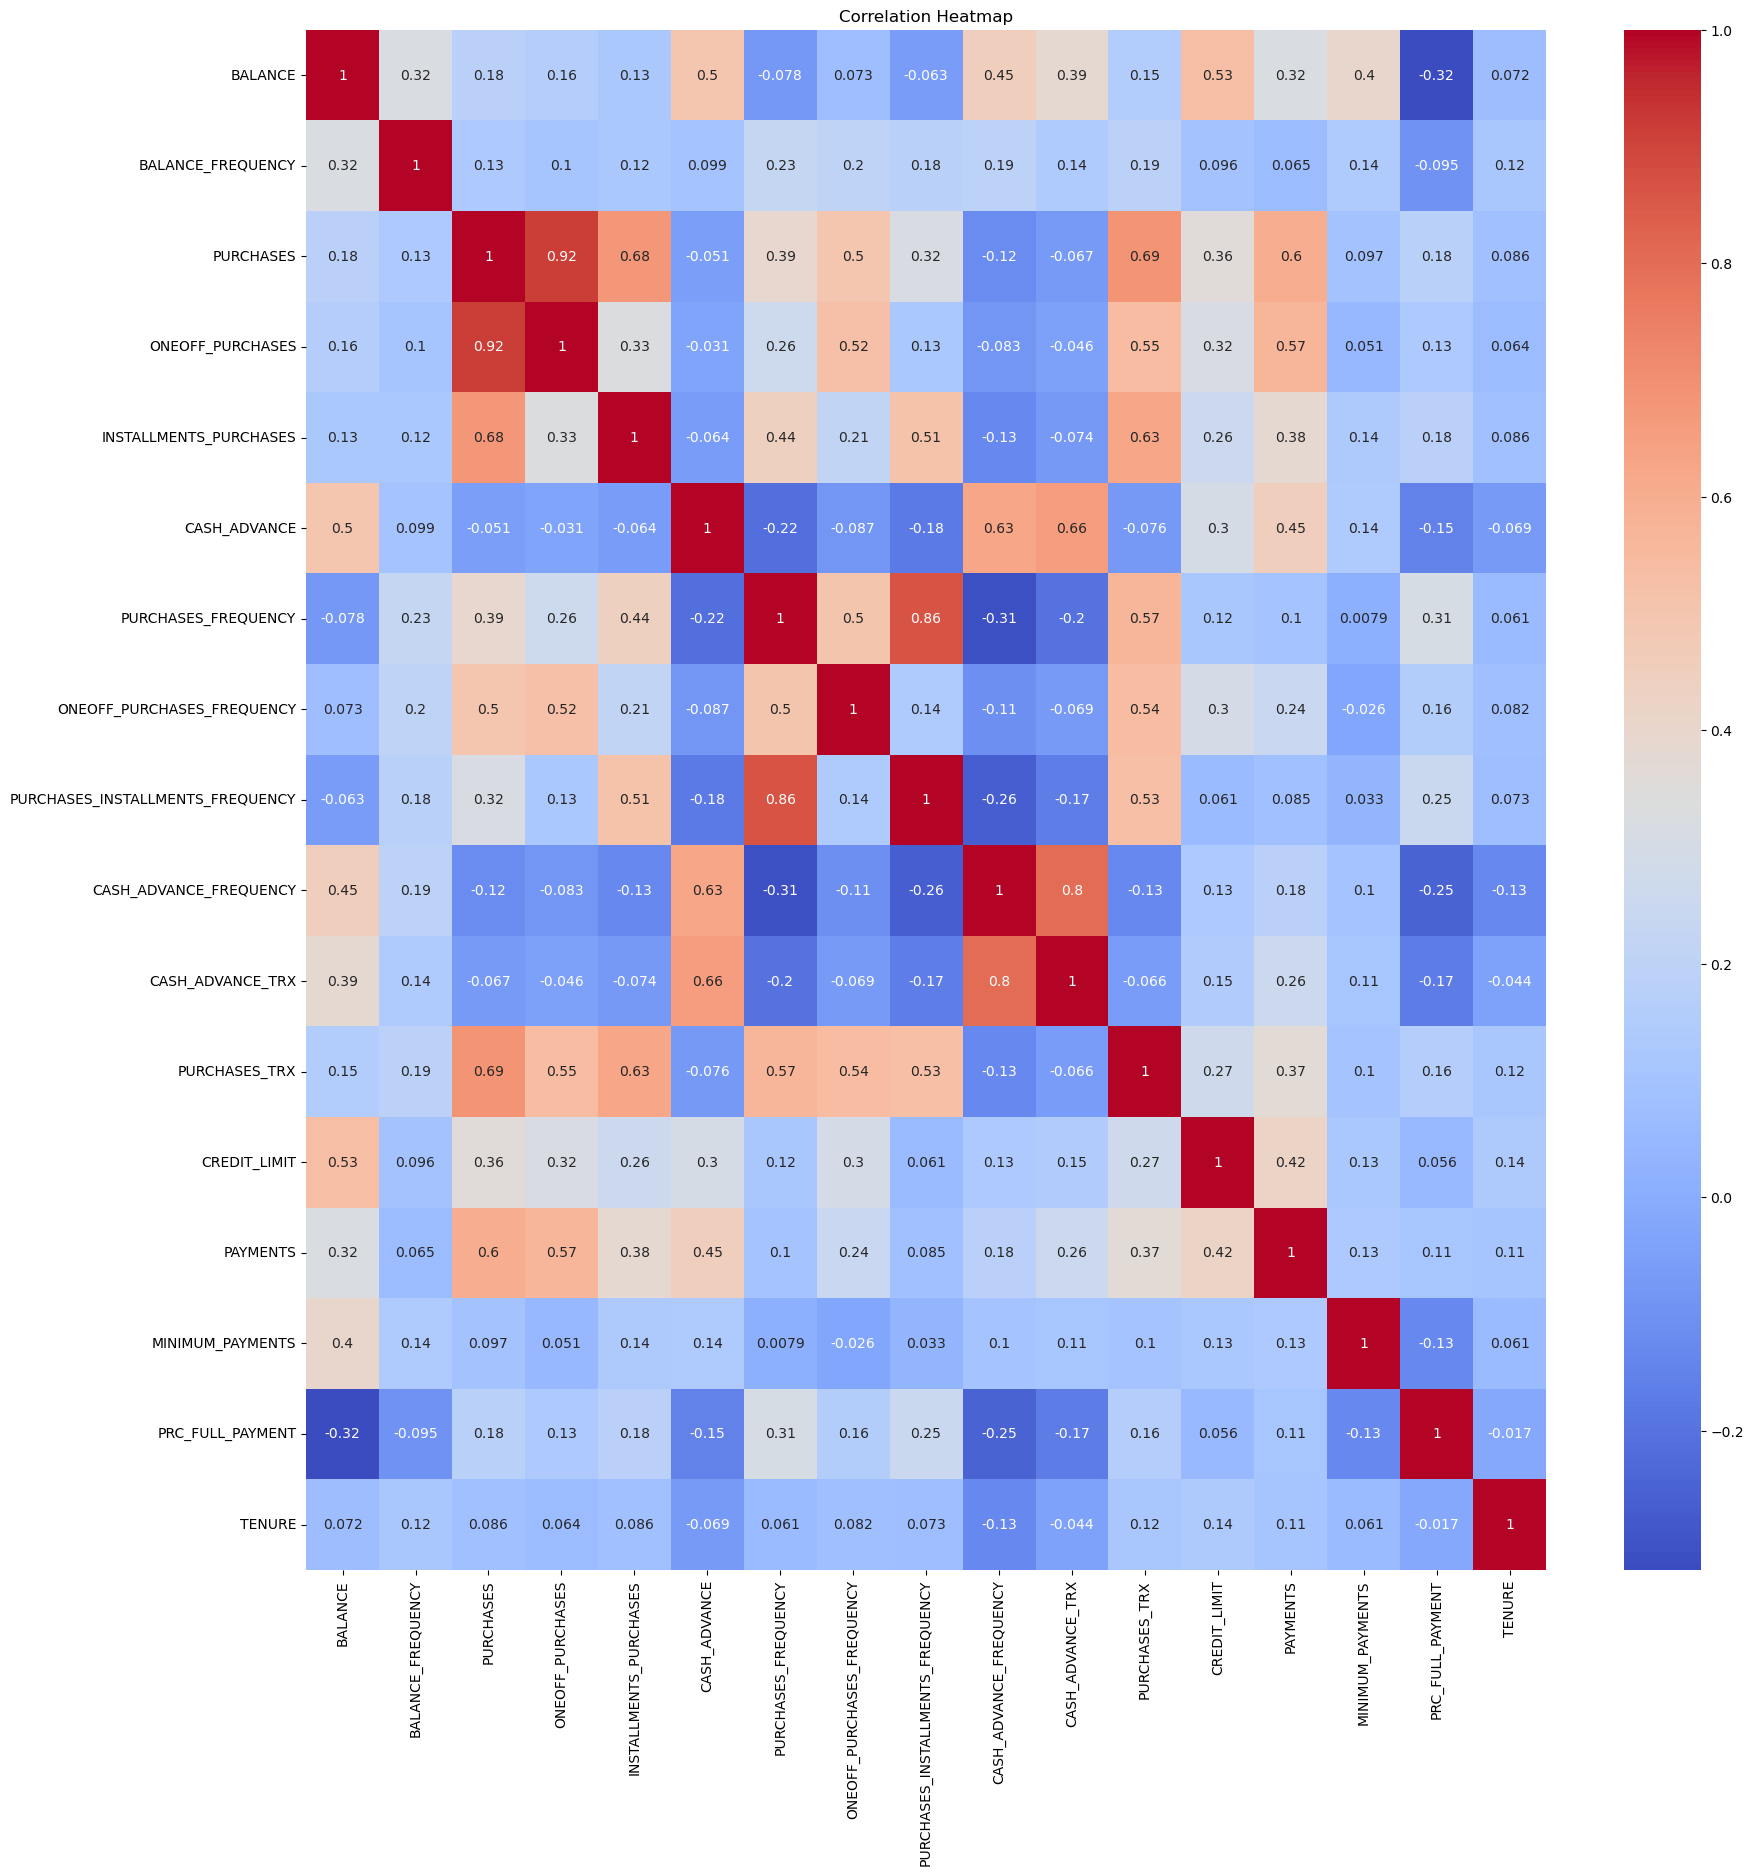

In [ ]:
# Find Correlations
df_corr = df.corr()
plt.figure(figsize = (20, 20))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Insights
# High, positive correlation is observed on
# Purchases v Oneoff Purchases, Installment Purchases, Purchases Trx, Payments
# Installment Purchases v Purchases Trx
# Cash Adv v Cash Adv Frequency, Cash Adv Trx
# Purchase Freq v Installment Freq
# Cash Adv Freq v Cash Adv Trx


In [ ]:
# # Outliers
# features = df.columns
# len(features)
# plt.figure(figsize=(20, 20))

# for feature in features:
#     plt.subplot(3,6, i+1)
#     sns.boxplot(data = df, x = df[''])

# for i, feature in enumerate(features[:3]):
#     plt.subplot(2, len(), i+1)
#     sns.boxplot(data=df, x=df['Gender'], y=df[feature])
#     plt.title(f'Boxplot of {features_title[i]} by Gender')
#     plt.xlabel('Gender')
#     plt.ylabel(feature)

# plt.tight_layout()
# plt.show()

# #

In [ ]:
df.shape

(8949, 21)

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
CREDIT_USE                          0
TENURE_LENGTH                       0
PAYMENT_RATIO                       0
CASH_ADV_RATIO                      0
dtype: int64


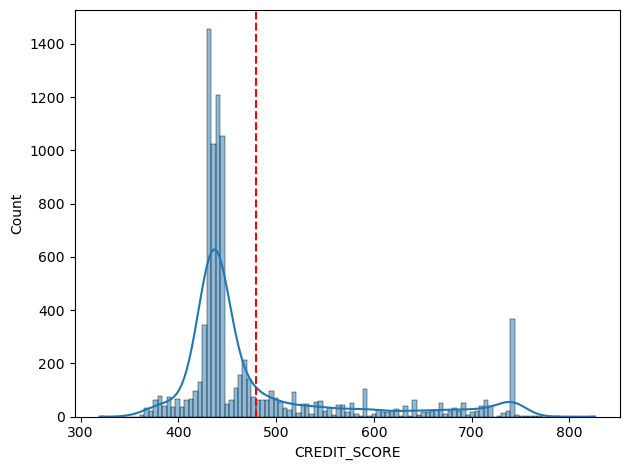

CREDIT_USE          0
PAYMENT_RATIO       0
CASH_ADV_RATIO      0
PRC_FULL_PAYMENT    0
TENURE_LENGTH       1
CREDIT_SCORE        1
dtype: int64


CREDIT_USE          5.637427e-02
PAYMENT_RATIO       4.218759e-02
CASH_ADV_RATIO      1.127623e-08
PRC_FULL_PAYMENT    0.000000e+00
TENURE_LENGTH                NaN
CREDIT_SCORE                 NaN
Name: 5203, dtype: float64

In [ ]:
# Calculated Features
## computing the credit score
# 'CREDIT_SCORE' = 35%'PRC_FULL_PAYMENT' + 30%'CREDIT_USE' + 15%'TENURE' + 10%'PAYMENT_RATIO' + 10%'CASH_ADV_RATIO'
# PRC_Full_Payment indicates payment consistency (payment history)


df_supervised = df
# Amount of credit used by customer. Nearly/maxing out the credit limit indicates a lower chance of customer paying
df_supervised['CREDIT_USE'] = df['BALANCE'] / df['CREDIT_LIMIT']

# Tenure indicates longevity of the user; Higher tenure indicates a more stable and trustworthy customer
df_supervised['TENURE_LENGTH'] = df['TENURE']/df['TENURE'].max()

# low payments large purchases indicates a lower chance of the customer paying;
# high payments low purchases indicates a higher chance of the customer paying
# the higher the payment_ratio, the better.
df_supervised['PAYMENT_RATIO'] = df['PAYMENTS'] / (df['PURCHASES'] + 0.0001)
#
# High cash_advance low balance indicates a lower chance of the customer paying;
# low cash_advance high balance indicates a higher chance of the customer paying
# the lower the cash_adv_ratio, the better.
df_supervised['CASH_ADV_RATIO'] = df['CASH_ADVANCE'] / (df['BALANCE'] + 0.0001)
print(df_supervised.isna().sum())
# scaling the dataset
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
orig_data = ['BALANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES', 'CASH_ADVANCE']
features= ['CREDIT_USE', 'PAYMENT_RATIO', 'CASH_ADV_RATIO', 'PRC_FULL_PAYMENT']
df_scaled_supervised = pd.DataFrame(scaler.fit_transform(df_supervised[features]), columns = features)
df_scaled_supervised['TENURE_LENGTH'] = df_supervised['TENURE_LENGTH']
df_scaled_supervised['CREDIT_SCORE'] = 35*df_scaled_supervised['PRC_FULL_PAYMENT'] + (1 - 30*df_scaled_supervised['CREDIT_USE']) +  15*df_scaled_supervised['TENURE_LENGTH'] + 10*df_scaled_supervised['PAYMENT_RATIO'] + (1 - 10*df_scaled_supervised['CASH_ADV_RATIO'])
df_scaled_supervised['CREDIT_SCORE'] = 300 + (df_scaled_supervised['CREDIT_SCORE']/100)*850 #scale the score from 300=850

criterion = df_scaled_supervised['CREDIT_SCORE'].mean()
sns.histplot(data=df_scaled_supervised, x='CREDIT_SCORE', kde = True)
plt.axvline(criterion, color = 'red', linestyle='--' )
plt.tight_layout()
plt.show()

print(df_scaled_supervised.isna().sum())
df_scaled_supervised[df_scaled_supervised.isnull().any(axis=1)]
df_scaled_supervised.iloc[5203]

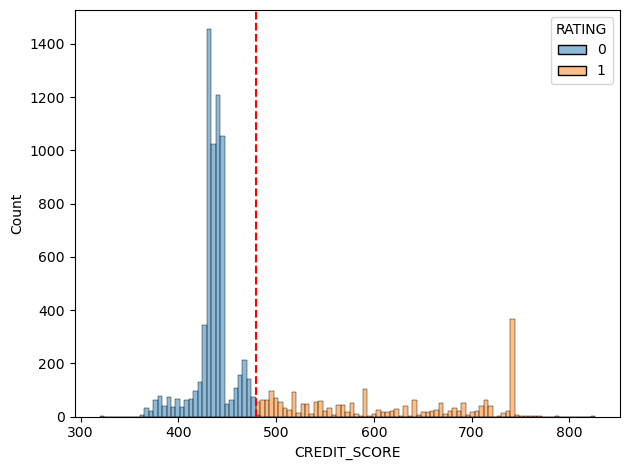

(8949, 12)

In [ ]:
## Supervised Learning
# Given the calculated credit score, we label the data points as 'good' or 'not good' to pay
# This trains a classification model that assesses a customer credit card spending and usage
# to predict its likelihood to pay back the credit card company

df_scaled_supervised['RATING'] = df_scaled_supervised['CREDIT_SCORE'].apply(lambda x: 1 if x >= criterion else 0)
sns.histplot(data=df_scaled_supervised, x='CREDIT_SCORE', hue = 'RATING')
plt.axvline(criterion, color = 'red', linestyle='--' )
plt.tight_layout()
plt.show()

df_scaled_supervised[orig_data] = df[orig_data]
df_scaled_supervised.shape

(7158, 11) (1790, 11)
[[1340    2]
 [   8  440]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1342
           1       1.00      0.98      0.99       448

    accuracy                           0.99      1790
   macro avg       0.99      0.99      0.99      1790
weighted avg       0.99      0.99      0.99      1790



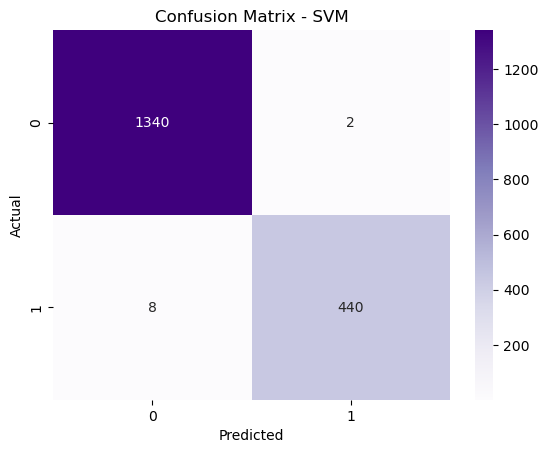

In [ ]:
from sklearn.svm import SVC
df_scaled_supervised = df_scaled_supervised.dropna()
df_scaled_supervised = pd.get_dummies(df_scaled_supervised, drop_first=True)
x = df_scaled_supervised.drop('RATING', axis=1)
y = df_scaled_supervised['RATING']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
model = SVC(kernel='rbf')
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
# pretty way to visualize confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()